# The overnight anomaly — quantitative analysis
### Real data, critical teardown, statistics, execution realism

Rigorous version of the [notebook for the curious](01_for_the_curious.ipynb). It tackles four questions a sceptical quant asks immediately:

1. **Does the pattern hold on real data, everywhere?** (spoiler: no — and that's instructive)
2. **Is the overnight Sharpe distinguishable from zero? Is it alpha or disguised beta?**
3. **Does it survive real execution costs?**
4. **Is the whole thing reproducible?**

> ⚠️ **Not investment advice.** Data: Yahoo! Finance via `yfinance`, adjustment mode `split_only` (choice documented in §3.3). First run hits the network.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from overnight import data, decompose, diagnostics, backtest, stats


## 1. The pattern on 10 world indices (ETFs)

We decompose each ETF into night / day and read the **annualised Sharpe of the overnight leg** — the only number that matters to judge an *edge*.

In [2]:
rows, decs = {}, {}
for tk, label in data.WORLD_INDICES.items():
    try:
        dec = decompose.decompose(data.fetch(tk, mode='split_only'))
    except Exception as e:
        print(f'{tk}: FAILED {e}'); continue
    decs[tk] = dec
    s = decompose.summary(dec)
    rows[tk] = {
        'market': label,
        'night cum %': s.loc['overnight','cum_return']*100,
        'day cum %': s.loc['intraday','cum_return']*100,
        'Sharpe night': s.loc['overnight','sharpe'],
        'Sharpe day': s.loc['intraday','sharpe'],
        'suspicious days': len(diagnostics.flag_suspicious_returns(dec)),
    }
table = pd.DataFrame(rows).T
table

,market,night cum %,day cum %,Sharpe night,Sharpe day,suspicious days
SPY,USA (S&P 500 ETF),"1,168.799",32.301,0.772,0.131,0
QQQ,USA (Nasdaq-100 ETF),"5,415.485",-49.931,0.706,0.005,1
EWU,UK (MSCI UK ETF),-84.812,516.902,-0.196,0.465,1
EWG,Germany (MSCI Germany ETF),-64.165,774.509,-0.068,0.511,0
EWQ,France (MSCI France ETF),-49.385,602.881,-0.019,0.493,0
EWJ,Japan (MSCI Japan ETF),-91.473,341.472,-0.190,0.443,1
EWH,Hong Kong (MSCI HK ETF),320.559,-60.281,0.324,-0.082,0
EWZ,Brazil (MSCI Brazil ETF),"4,680.213",-96.231,0.696,-0.335,0
INDA,India (MSCI India ETF),233.728,-46.912,0.550,-0.340,0
FXI,China (large-cap ETF),244.453,69.206,0.263,0.224,1


Quick read: the **US (SPY, QQQ)** and **Brazil** show the classic pattern (huge night, weak or negative day, night Sharpe ~0.7). But look at **Europe (UK, Germany, France)** and **Japan**: the pattern is **inverted**. That's not a detail — it's the heart of the teardown.

## 2. Critical teardown

### 2.1 The foreign-ETF inversion: we're measuring the time zone, not an anomaly

Let's visualise night vs day Sharpe by market:

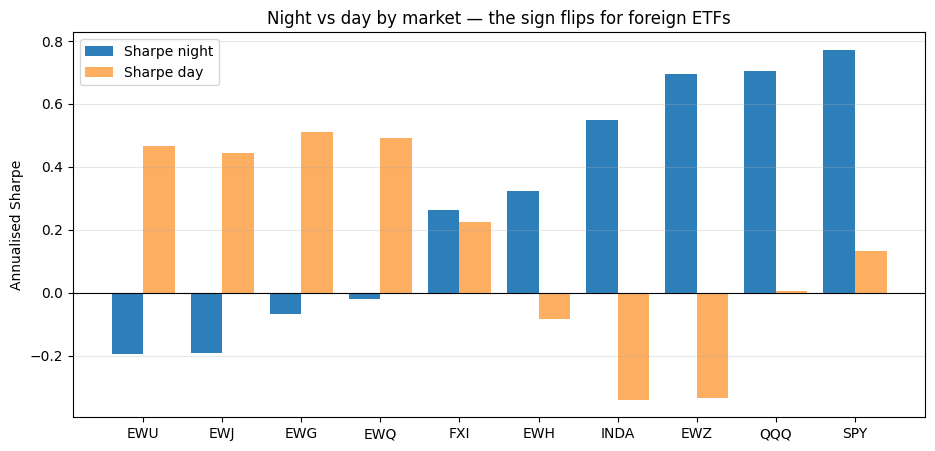

In [3]:
t = table.sort_values('Sharpe night')
x = np.arange(len(t)); w = 0.4
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x-w/2, t['Sharpe night'].astype(float), w, label='Sharpe night', color='#2c7fb8')
ax.bar(x+w/2, t['Sharpe day'].astype(float), w, label='Sharpe day', color='#fdae61')
ax.axhline(0, color='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(t.index)
ax.set_ylabel('Annualised Sharpe'); ax.set_title('Night vs day by market — the sign flips for foreign ETFs')
ax.legend(); ax.grid(axis='y', alpha=.3); plt.show()

**Microstructure explanation.** EWU, EWG, EWQ, EWJ are ETFs listed in New York but whose underlying (London, Frankfurt, Paris, Tokyo) **trades during the US night**. For these products, the "overnight" window (US clock, close→open) **contains the home market's session**, while the US "intraday" window falls when the underlying is largely closed (the price only moves via NAV arbitrage).

In other words: **the night/day split is relative to the listing clock**. Applied to an instrument offset from its market, it mostly measures the time zone — not an "anomaly". A single global manipulator would struggle to explain why the sign depends on where the ETF is *listed*. This is a major caution, and a reminder: **always check what the time window actually captures for the chosen instrument.**

### 2.2 The China test and the T+1 rule

For Chinese stocks, the literature (Qiao & Dam, 2020) documents an **inverted** pattern (positive day, negative night), cleanly explained by the **T+1** rule (shares bought one day cannot be sold before the next). Our ETF proxy (FXI, US-listed) doesn't directly test A-shares, but we note a much weaker signal than for the US:

In [4]:
if 'FXI' in decs:
    s = decompose.summary(decs['FXI'])
    print('China (FXI) — night Sharpe: {:+.2f}  vs  US (SPY): {:+.2f}'.format(
        s.loc['overnight','sharpe'], decompose.summary(decs['SPY']).loc['overnight','sharpe']))
    print('A universal, orchestrated pattern should be more geographically homogeneous.')

China (FXI) — night Sharpe: +0.26  vs  US (SPY): +0.77
A universal, orchestrated pattern should be more geographically homogeneous.


### 2.3 Compounding and selection

As shown in the notebook for the curious, log-scale magnitudes are dominated by **compounding** (a 1 bps bias → +124% over 32 years) and by **selection** (the most spectacular figures are, by the author's own admission, "the 25 most problematic"). The **suspicious-days counter** (column in §1) stays low here because the US ETFs are clean — the artefacts live mostly in the **raw emerging spot indices** (e.g. `^BSESN`), not these ETFs. A caveat to keep for any reproduction of the famous India Figure 8.

## 3. Statistical rigour & risk

### 3.1 Is the overnight Sharpe distinguishable from zero? (bootstrap)

Could a Sharpe of 0.77 on a finite sample be noise? 95% confidence interval by bootstrap (2000 resamples):

In [5]:
for tk in ['SPY','QQQ','EWZ','FXI']:
    if tk not in decs: continue
    r = stats.sharpe_ci_bootstrap(decs[tk]['r_overnight'], n_boot=2000, seed=0)
    print(f"{tk:4s} night Sharpe = {r['sharpe']:+.2f}  "
          f"95% CI [{r['ci_low']:+.2f}, {r['ci_high']:+.2f}]  "
          f"P(Sharpe<0) = {r['frac_negative']:.1%}  (n={r['n_obs']})")

SPY  night Sharpe = +0.77  95% CI [+0.43, +1.12]  P(Sharpe<0) = 0.0%  (n=8394)


QQQ  night Sharpe = +0.71  95% CI [+0.50, +1.24]  P(Sharpe<0) = 0.0%  (n=6852)


EWZ  night Sharpe = +0.70  95% CI [+0.29, +1.12]  P(Sharpe<0) = 0.0%  (n=6511)


FXI  night Sharpe = +0.26  95% CI [-0.17, +0.52]  P(Sharpe<0) = 9.3%  (n=5448)


For SPY/QQQ/Brazil the interval clears zero by a wide margin: the effect is **statistically real**. So the question is not *"does it exist?"* but *"is it exploitable alpha?"* — hence the next two sections.

### 3.2 Alpha, or disguised beta?

Holding the market *every night* means carrying **gap risk** permanently. So part of the "overnight alpha" is a **beta risk premium**, not a distinct edge. We regress the night leg on the market (close-close): `r_night = α + β·r_market + ε`.

In [6]:
d = stats.beta_decomposition(decs['SPY'], leg='overnight')
print('SPY — overnight leg regressed on the market (close-close):')
print(f"  beta = {d['beta']:.2f}   R^2 = {d['r_squared']:.2f}")
print(f"  mean overnight return = {d['mean_leg_bps']:.2f} bps/day")
print(f"     of which beta*market = {d['beta_contrib_bps']:.2f} bps   (risk premium)")
print(f"     of which resid. alpha = {d['alpha_daily_bps']:.2f} bps   ({d['alpha_ann_pct']:+.1f}%/yr)")

SPY — overnight leg regressed on the market (close-close):
  beta = 0.33   R^2 = 0.33
  mean overnight return = 3.25 bps/day
     of which beta*market = 1.33 bps   (risk premium)
     of which resid. alpha = 1.92 bps   (+5.0%/yr)


Two readings, both unfavourable to the easy-edge thesis:

- **~40% of the overnight return is beta** (beta ≈ 0.33 on SPY): holding the market overnight is partly a plain **gap-risk premium**, not distinct alpha.
- More importantly, the **residual alpha (~1.9 bps/day) is *below* the break-even cost (~3.25 bps)** computed in §4: even the "non-beta" part of the return does not survive execution fees. That's the nail in the coffin — you must charge costs against the alpha, not the gross return.

### 3.3 Sensitivity to the dividend-adjustment mode

The adjustment mode is **not a detail**: a stock goes ex-dividend at the **open**, so adjustment shifts return between night and day. Compare `split_only` (default, keeps the ex-div gap in the night) vs `total_return` (fully adjusted) on SPY:

In [7]:
spy_tr = decompose.decompose(data.fetch('SPY', mode='total_return'))
spy_so = decs['SPY']
print('SPY — overnight cumulative:')
print(f"  split_only   : {spy_so['cum_overnight'].iloc[-1]*100:+,.0f}%")
print(f"  total_return : {spy_tr['cum_overnight'].iloc[-1]*100:+,.0f}%")
print('The choice shifts the level of the night leg -> document it in any published figure.')

SPY — overnight cumulative:
  split_only   : +1,169%


  total_return : +2,206%
The choice shifts the level of the night leg -> document it in any published figure.


## 4. Execution realism

Cost model per night held:
`cost = 2*(0.5*spread + commission + slippage) + financing`. The **factor 2** (you cross the spread to buy *and* to sell, ~252×/yr) is the killer. Break-even and sweep on SPY:

In [8]:
be = backtest.breakeven_cost_bps(spy_so)
print(f'Break-even round-trip cost = {be:.2f} bps/night')
sweep = backtest.cost_sweep(spy_so, roundtrip_bps=(0,1,2,3,5,8))
sweep.round(3)

Break-even round-trip cost = 3.25 bps/night


,cagr_net,sharpe_net,max_drawdown
roundtrip_bps,,,
0,0.079,0.772,-0.348
1,0.052,0.535,-0.378
2,0.026,0.297,-0.496
3,0.001,0.060,-0.687
5,-0.049,-0.415,-0.890
8,-0.118,-1.127,-0.985


The gross edge survives only a few basis points. Three retail-side aggravating factors, not captured by this *optimistic* backtest:

- **Execution price ≠ academic prints**: the anomaly is measured on the close/open auctions, inaccessible to retail; at T±5 min you're in continuous trading, with a wider spread.
- **CFD / MT5 swap**: the overnight financing charged each night can erase the edge on its own (check `swap_long` before any trade — exactly the safeguard implemented in the repo's MT5 connector).
- **Capacity / slippage**: market impact grows with order size, especially on thin auctions.

## 5. Reproducibility

- **Determinism**: all synthetic data and the bootstrap are *seeded*.
- **Tests**: `pytest` verifies the decomposition identity `(1+r_night)(1+r_day)=(1+r_cc)` (error ~1e-16) and cost monotonicity.
- **CI**: GitHub Actions reruns tests + the offline demo on Python 3.10–3.12.
- **Data**: local parquet cache (`_cache/`), explicit adjustment mode.
- **Generated notebooks**: `python notebooks/build_notebooks.py` then `nbconvert --execute` — the figure you read is the executed output, not a screenshot.

## 6. Honest verdict

Three levels never to be conflated:

1. **The empirical fact is REAL** and well documented (Lou-Polk-Skouras 2019, Cooper-Cliff-Gulen 2008, NY Fed). Credit to Knuteson for publishing data and code.
2. **The magnitudes are INFLATED** — 30-year compounding + log scale, data artefacts, selection/survivorship bias.
3. **The attribution to orchestrated fraud is NOT proven** — the foreign-ETF inversion (time zone) and the Chinese case (T+1) favour **microstructure** explanations, and most of the "overnight return" is **gap beta**, not alpha.

And even assuming the edge is real: **it does not survive real execution costs** — as the 2023 liquidation of the NSPY / NIWM ETFs showed. A beautiful anomaly for understanding microstructure; a poor retail trading strategy.